# Roman-Cuts

A short tutorial on how to use `RomanCuts` to get cutouts from simulated images created with `RImTimSim` [Link](https://github.com/robertfwilson/rimtimsim).

In [1]:
!ulimit -n 

4864


In [2]:
import os
import numpy as np
from glob import glob
from roman_cuts import RomanCuts
import matplotlib.pyplot as plt

In [29]:
PATH = "/Users/jimartin/Work/ROMAN/TRExS/simulations/dryrun_01"
# PATH = "/Volumes/JorgeMarpa-2T/trexs/dryrun_01/"

FILTER = "F146"
SCA = 2
FIELD = 3

In [30]:
# get path for all FITS files in disk
ff = sorted(glob(f"{PATH}/simulated_image_data/rimtimsim_WFI_lvl02_{FILTER}_SCA{SCA:02}_field{FIELD:02}_rampfitted_exposureno_*_sim.fits"))
print(f"There are {len(ff)} frames available in {FILTER}")

There are 3298 frames available in F146


In [19]:
# initialize RomanCuts object
rcube = RomanCuts(field=3, sca=1, filter="F146", file_list=ff, file_format="fits")
rcube

Roman WFI Field 3 SCA 1 Filter F146 Frames 131

## Fixed pixel coordinates

In [20]:
# make a cutout using pixel row and column coordinates
# with dithered=False the cutouts will be fixed tothe pixel grid
rcube.make_cutout(rowcol=(1920, 1920), size=(256, 256), dithered=False)

Extracting cutout: 100%|███████████████████████████████████████████████████████████████████| 131/131 [00:00<00:00, 1157.34it/s]


In [21]:
# this is the center of the cutout 
rcube.ra, rcube.dec

(array(268.49141932), array(-29.2060357))

In [22]:
# we have the flux and errors in 3d arrays
rcube.flux.shape, rcube.flux_err.shape

((131, 256, 256), (131, 256, 256))

In [23]:
# we have the time, cadence numbe and quality flags
rcube.time.shape, rcube.exposureno.shape, rcube.quality.shape

((131,), (131,), (131,))

In [24]:
# and the metadata
rcube.metadata

{'MISSION': 'Roman-Sim',
 'TELESCOP': 'Roman',
 'CREATOR': 'TRExS-roman-cuts',
 'SOFTWARE': 'rimtimsim_v2.0',
 'RADESYS': 'FK5',
 'EQUINOX': 2000.0,
 'FILTER': 'F213',
 'FIELD': 3,
 'DETECTOR': 'SCA02',
 'EXPOSURE': 54.72,
 'READMODE': 'rampfitted',
 'TSTART': 2461451.013273377,
 'TEND': 2461520.126052503,
 'RA_CEN': 268.49141932159233,
 'DEC_CEN': -29.206035695930808,
 'DITHERED': False,
 'NTIMES': 131,
 'IMGSIZE': (256, 256)}

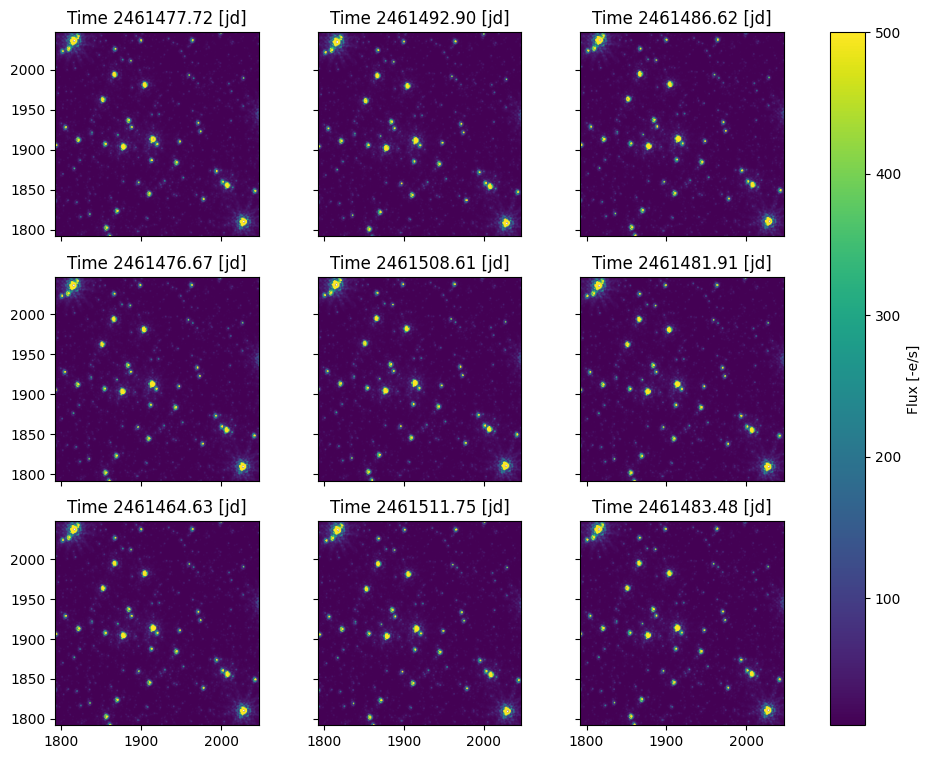

In [25]:
# we can check a few stamps

fig, ax = plt.subplots(3,3, sharex=True, sharey=True, figsize=(12,9))
tdx = np.random.choice(np.arange(rcube.nt), size=9, replace=False)
for axis, t in zip(ax.ravel(), tdx):
    bar = axis.imshow(rcube.flux[t], 
                origin="lower", 
                vmin=10, 
                vmax=500, 
                extent=(rcube.row.min(), rcube.row.max(), rcube.column.min(), rcube.column.max()),
               )
    axis.set_title(f"Time {rcube.time[t]:.2f} [jd]")
plt.colorbar(bar, ax=ax, location="right", label="Flux [-e/s]" )
plt.show()

In [26]:
# we save the cutout to disk as ASDF file 
rcube.save_cutout(output=f"./rimtimsim_WFI_lvl02_{FILTER}_SCA{SCA:02}_field{FIELD:02}_rampfitted_r1920c1920_256x256_sim.asdf")

In [27]:
!pwd

/Users/jimartin/Work/ROMAN/TRExS/roman-cuts/notebooks


In [ ]:
import asdf

In [ ]:
af = asdf.open("./test.asdf")
af.info()

## Accounting for Dithering

In [ ]:
# we can use sky coordinates to center the cutout
# the target will be centeredaccounting for dithering
radec = (268.5112137932491, -29.24473947250156)

In [ ]:
# we can request all WCSs, it will take a few seconds more
rcube.make_cutout(radec=radec, size=(15, 15), dithered=True)

In [ ]:
rcube.flux.shape

In [ ]:
# this time row and columns are [nt, npix]
rcube.row, rcube.column

In [ ]:
# visual check of the cutouts centered in the target
Ts = np.random.choice(np.arange(rcube.nt), size=5*5, replace=False)

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column[t], rcube.row[t], rcube.flux[t], vmin=10, vmax=500)
    axis.scatter(rcube.target_pixel[t, 1],rcube.target_pixel[t, 0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()

In [ ]:
# we can save the file to disk with default name
rcube.save_cutout()

In [ ]:
# this one contains all the WCS per frame in the ASDF
af = asdf.open("./roman_cutout_field03_SCA02_268.5112_-29.2447_s15x15.asdf")
af.info()

In [ ]:
# row and column in the ASDF have the lower-left corner pixel for each time
# we can reconstruct the pixel grid at each time with that and the cutout size.
af["roman"]["data"]["row"], af["roman"]["data"]["column"]